In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
# ==============================
# LoyaltyRadar v2
# Notebook 02: Basic EDA and Customer Behavior
# ==============================

#loading the clean merged file from NB 01.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

BASE_DIR = Path("/content/drive/MyDrive/LoyaltyRadar")

PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "data" / "outputs"
FIGURE_DIR = BASE_DIR / "reports" / "figures"

df = pd.read_csv(PROCESSED_DIR / "01_merged_base.csv")

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (391014, 30)


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

BASE_DIR = Path("/content/drive/MyDrive/LoyaltyRadar")

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "data" / "outputs"
FIGURE_DIR = BASE_DIR / "reports" / "figures"
MODEL_DIR = BASE_DIR / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Setup done")

Setup done


In [95]:
#converting date text back to dates
date_cols = [
    "activity_date",
    "start_of_year",
    "start_of_quarter",
    "start_of_month",
    "enrollment_date",
    "cancellation_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[date_cols].dtypes)

activity_date        datetime64[ns]
start_of_year        datetime64[ns]
start_of_quarter     datetime64[ns]
start_of_month       datetime64[ns]
enrollment_date      datetime64[ns]
cancellation_date    datetime64[ns]
dtype: object


In [96]:
#Quick sanity check
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique customers:", df["loyalty_number"].nunique())
print("Date range:", df["activity_date"].min(), "to", df["activity_date"].max())

print("\nTop missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

display(df.head())

Rows: 391014
Columns: 30
Unique customers: 16737
Date range: 2017-01-01 00:00:00 to 2018-12-01 00:00:00

Top missing values:


,0
cancellation_date,342859
cancellation_month,342859
cancellation_year,342859
salary,99136
loyalty_number,0
year,0
points_redeemed,0
dollar_cost_points_redeemed,0
activity_date,0
start_of_year,0


,loyalty_number,year,month,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,activity_date,start_of_year,start_of_quarter,start_of_month,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,formal_churn,enrollment_date,cancellation_date
0,100590,2018,6,12,15276,22914.0,0,0,2018-06-01,2018-01-01,2018-04-01,2018-06-01,Canada,British Columbia,Vancouver,V6E 3Z3,Female,Bachelor,69841.0,Married,Star,34090.04,2018 Promotion,2018,3,NaN,NaN,0,2018-03-01,NaT
1,100590,2018,7,12,9168,13752.0,0,0,2018-07-01,2018-01-01,2018-07-01,2018-07-01,Canada,British Columbia,Vancouver,V6E 3Z3,Female,Bachelor,69841.0,Married,Star,34090.04,2018 Promotion,2018,3,NaN,NaN,0,2018-03-01,NaT
2,100590,2018,5,4,6504,9756.0,0,0,2018-05-01,2018-01-01,2018-04-01,2018-05-01,Canada,British Columbia,Vancouver,V6E 3Z3,Female,Bachelor,69841.0,Married,Star,34090.04,2018 Promotion,2018,3,NaN,NaN,0,2018-03-01,NaT
3,100590,2018,10,0,0,0.0,512,92,2018-10-01,2018-01-01,2018-10-01,2018-10-01,Canada,British Columbia,Vancouver,V6E 3Z3,Female,Bachelor,69841.0,Married,Star,34090.04,2018 Promotion,2018,3,NaN,NaN,0,2018-03-01,NaT
4,100590,2018,2,0,0,0.0,0,0,2018-02-01,2018-01-01,2018-01-01,2018-02-01,Canada,British Columbia,Vancouver,V6E 3Z3,Female,Bachelor,69841.0,Married,Star,34090.04,2018 Promotion,2018,3,NaN,NaN,0,2018-03-01,NaT


In [97]:
#customer-month uniqueness
#For monthly data, ideally each customer should have only one row per month.
#So this combination should be unique:
#loyalty_number + activity_date
# Check if one customer has only one row per month
duplicate_customer_months = df.duplicated(subset=["loyalty_number", "activity_date"]).sum()

print("Duplicate customer-month rows:", duplicate_customer_months)
print("Total rows:", df.shape[0])

Duplicate customer-month rows: 1949
Total rows: 391014


In [98]:
#months per customer
#Since flight activity data covers 24 months, a customer can have max 24 monthly records.
customer_month_counts = df.groupby("loyalty_number")["activity_date"].nunique()

print("Minimum months per customer:", customer_month_counts.min())
print("Maximum months per customer:", customer_month_counts.max())
print("Average months per customer:", round(customer_month_counts.mean(), 2))

display(customer_month_counts.value_counts().sort_index())

Minimum months per customer: 11
Maximum months per customer: 24
Average months per customer: 23.25


,count
activity_date,
11,971
24,15766


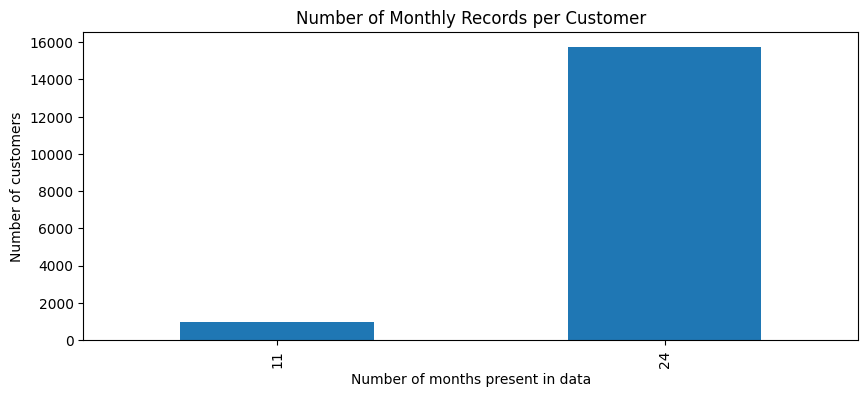

In [99]:
#Ploting months per customer
customer_month_counts.value_counts().sort_index().plot(kind="bar", figsize=(10, 4))

plt.title("Number of Monthly Records per Customer")
plt.xlabel("Number of months present in data")
plt.ylabel("Number of customers")
plt.show()

Observation:
The customer-month level check shows 1,949 duplicate customer-month combinations. Since the flight activity table is expected to represent monthly customer activity, each customer should ideally have one row per month. These duplicates need to be inspected before modelling because they can inflate activity, points, and churn-related features if not handled correctly.

Observation:
Most customers have complete 24-month activity history, but 971 customers have only 11 monthly records. This suggests that a subset of customers enters the activity dataset later, likely during 2018. This matters for behavioral churn modelling because customers with shorter history should not be treated the same as full-history customers when creating inactivity-based churn labels or trend features.

In [100]:
#Extracting duplicate customer-month rows
#We are checking whether these duplicate rows are truly repeated or whether they contain different values.
dupe_rows = df[df.duplicated(subset=["loyalty_number", "activity_date"], keep=False)]

print("Duplicate customer-month rows shape:", dupe_rows.shape)

display(
    dupe_rows
    .sort_values(["loyalty_number", "activity_date"])
    .head(30)
)

Duplicate customer-month rows shape: (3892, 30)


,loyalty_number,year,month,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,activity_date,start_of_year,start_of_quarter,start_of_month,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,formal_churn,enrollment_date,cancellation_date
137472,101902,2017,4,1,667,667.0,0,0,2017-04-01,2017-01-01,2017-04-01,2017-04-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
149793,101902,2017,4,1,2499,2499.0,488,88,2017-04-01,2017-01-01,2017-04-01,2017-04-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
55777,101902,2017,5,3,7263,7263.0,0,0,2017-05-01,2017-01-01,2017-04-01,2017-05-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
97849,101902,2017,5,2,3762,3762.0,0,0,2017-05-01,2017-01-01,2017-04-01,2017-05-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
57365,101902,2017,6,3,4971,4971.0,0,0,2017-06-01,2017-01-01,2017-04-01,2017-06-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
57366,101902,2017,6,3,5763,5763.0,0,0,2017-06-01,2017-01-01,2017-04-01,2017-06-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
11348,101902,2017,8,5,3825,3825.0,0,0,2017-08-01,2017-01-01,2017-07-01,2017-08-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
28437,101902,2017,8,4,8952,8952.0,0,0,2017-08-01,2017-01-01,2017-07-01,2017-08-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
103177,101902,2017,9,2,3734,3734.0,0,0,2017-09-01,2017-01-01,2017-07-01,2017-09-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
144439,101902,2017,9,1,2187,2187.0,0,0,2017-09-01,2017-01-01,2017-07-01,2017-09-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT


In [101]:
#Checking if duplicates are exact same rows
#If duplicate customer-month rows are also exact duplicates, we can safely remove them.
#If they are not exact duplicates, we may need to aggregate them.
exact_duplicate_count = dupe_rows.duplicated().sum()

print("Rows inside duplicate customer-month group:", dupe_rows.shape[0])
print("Exact duplicate rows among them:", exact_duplicate_count)

Rows inside duplicate customer-month group: 3892
Exact duplicate rows among them: 0


In [102]:
#Compareing duplicate activity values
#We are checking whether duplicate rows have different values for flights/distance/points.If values differ, then they may represent separate activity records in the same month and should be summed.If values are same, they are likely accidental duplicates.
dupe_summary = (
    dupe_rows
    .groupby(["loyalty_number", "activity_date"])
    .agg(
        row_count=("loyalty_number", "size"),
        total_flights_sum=("total_flights", "sum"),
        total_flights_unique=("total_flights", "nunique"),
        distance_sum=("distance", "sum"),
        distance_unique=("distance", "nunique"),
        points_accumulated_sum=("points_accumulated", "sum"),
        points_accumulated_unique=("points_accumulated", "nunique"),
        points_redeemed_sum=("points_redeemed", "sum"),
        points_redeemed_unique=("points_redeemed", "nunique")
    )
    .reset_index()
)

display(dupe_summary.head(20))

print("How many duplicate groups have different total_flights?")
print((dupe_summary["total_flights_unique"] > 1).sum())

print("How many duplicate groups have different distance?")
print((dupe_summary["distance_unique"] > 1).sum())

print("How many duplicate groups have different points_accumulated?")
print((dupe_summary["points_accumulated_unique"] > 1).sum())

,loyalty_number,activity_date,row_count,total_flights_sum,total_flights_unique,distance_sum,distance_unique,points_accumulated_sum,points_accumulated_unique,points_redeemed_sum,points_redeemed_unique
0,101902,2017-04-01,2,2,1,3166,2,3166.0,2,488,2
1,101902,2017-05-01,2,5,2,11025,2,11025.0,2,0,1
2,101902,2017-06-01,2,6,1,10734,2,10734.0,2,0,1
3,101902,2017-08-01,2,9,2,12777,2,12777.0,2,0,1
4,101902,2017-09-01,2,3,2,5921,2,5921.0,2,0,1
5,101902,2017-10-01,2,3,2,2740,2,2740.0,2,0,1
6,101902,2017-11-01,2,2,2,1574,2,1574.0,2,0,1
7,101902,2018-01-01,2,2,2,2112,2,2112.0,2,0,1
8,101902,2018-02-01,2,2,2,3064,2,3064.0,2,0,1
9,101902,2018-03-01,2,3,2,7165,2,7165.0,2,0,1


How many duplicate groups have different total_flights?
1753
How many duplicate groups have different distance?
1932
How many duplicate groups have different points_accumulated?
1932


Observation:
The dataset contains 1,946 customer-month combinations with more than one row. These rows are not exact duplicates; the activity values such as flights, distance, points accumulated, and points redeemed differ across rows. This suggests that some monthly customer activity may be split into multiple records rather than stored as one monthly total. For modelling and customer behavior analysis, the data should be aggregated to one row per customer per month by summing activity columns and keeping customer profile fields unchanged.

In [103]:
#Counting duplicate groups
duplicate_groups = (
    df.groupby(["loyalty_number", "activity_date"])
    .size()
    .reset_index(name="row_count")
)

print("Total customer-month groups:", duplicate_groups.shape[0])
print("Groups with more than 1 row:", (duplicate_groups["row_count"] > 1).sum())

display(duplicate_groups["row_count"].value_counts().sort_index())

Total customer-month groups: 389065
Groups with more than 1 row: 1943


,count
row_count,
1,387122
2,1937
3,6


In [104]:
#Aggregate customer-month data
activity_cols = [
    "total_flights",
    "distance",
    "points_accumulated",
    "points_redeemed",
    "dollar_cost_points_redeemed"
]

group_cols = ["loyalty_number", "activity_date"]

profile_cols = [col for col in df.columns if col not in activity_cols + group_cols]

agg_dict = {}

for col in activity_cols:
    agg_dict[col] = "sum"

for col in profile_cols:
    agg_dict[col] = "first"

df_monthly = (
    df.groupby(group_cols, as_index=False)
    .agg(agg_dict)
)

print("Original df shape:", df.shape)
print("After customer-month aggregation:", df_monthly.shape)

print("Duplicate customer-month rows after aggregation:")
print(df_monthly.duplicated(subset=["loyalty_number", "activity_date"]).sum())

Original df shape: (391014, 30)
After customer-month aggregation: (389065, 30)
Duplicate customer-month rows after aggregation:
0


In [105]:
#Checking one example customer after aggregation
display(
    df[df["loyalty_number"] == 101902]
    .sort_values("activity_date")
    .head(10)
)

display(
    df_monthly[df_monthly["loyalty_number"] == 101902]
    .sort_values("activity_date")
    .head(10)
)

,loyalty_number,year,month,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,activity_date,start_of_year,start_of_quarter,start_of_month,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,formal_churn,enrollment_date,cancellation_date
177032,101902,2017,1,0,0,0.0,0,0,2017-01-01,2017-01-01,2017-01-01,2017-01-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
186927,101902,2017,2,0,0,0.0,0,0,2017-02-01,2017-01-01,2017-01-01,2017-02-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
196643,101902,2017,3,0,0,0.0,0,0,2017-03-01,2017-01-01,2017-01-01,2017-03-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
149793,101902,2017,4,1,2499,2499.0,488,88,2017-04-01,2017-01-01,2017-04-01,2017-04-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
137472,101902,2017,4,1,667,667.0,0,0,2017-04-01,2017-01-01,2017-04-01,2017-04-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
55777,101902,2017,5,3,7263,7263.0,0,0,2017-05-01,2017-01-01,2017-04-01,2017-05-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
97849,101902,2017,5,2,3762,3762.0,0,0,2017-05-01,2017-01-01,2017-04-01,2017-05-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
57365,101902,2017,6,3,4971,4971.0,0,0,2017-06-01,2017-01-01,2017-04-01,2017-06-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
57366,101902,2017,6,3,5763,5763.0,0,0,2017-06-01,2017-01-01,2017-04-01,2017-06-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
233449,101902,2017,7,0,0,0.0,0,0,2017-07-01,2017-01-01,2017-07-01,2017-07-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT


,loyalty_number,activity_date,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,year,month,start_of_year,start_of_quarter,start_of_month,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,formal_churn,enrollment_date,cancellation_date
971,101902,2017-01-01,0,0,0.0,0,0,2017,1,2017-01-01,2017-01-01,2017-01-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
972,101902,2017-02-01,0,0,0.0,0,0,2017,2,2017-01-01,2017-01-01,2017-02-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
973,101902,2017-03-01,0,0,0.0,0,0,2017,3,2017-01-01,2017-01-01,2017-03-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
974,101902,2017-04-01,2,3166,3166.0,488,88,2017,4,2017-01-01,2017-04-01,2017-04-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
975,101902,2017-05-01,5,11025,11025.0,0,0,2017,5,2017-01-01,2017-04-01,2017-05-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
976,101902,2017-06-01,6,10734,10734.0,0,0,2017,6,2017-01-01,2017-04-01,2017-06-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
977,101902,2017-07-01,0,0,0.0,0,0,2017,7,2017-01-01,2017-07-01,2017-07-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
978,101902,2017-08-01,9,12777,12777.0,0,0,2017,8,2017-01-01,2017-07-01,2017-08-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
979,101902,2017-09-01,3,5921,5921.0,0,0,2017,9,2017-01-01,2017-07-01,2017-09-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT
980,101902,2017-10-01,3,2740,2740.0,0,0,2017,10,2017-01-01,2017-10-01,2017-10-01,Canada,Ontario,London,M5B 3E4,Female,College,NaN,Married,Aurora,6265.34,Standard,2017,1,NaN,NaN,0,2017-01-01,NaT


Observation:
The dataset contained 1,943 customer-month combinations with multiple rows. These were not exact duplicates, because activity values such as flights, distance, points accumulated, and points redeemed differed across rows. This suggests that some monthly customer activity was split into multiple records. Since the project requires customer-month level behavior, these rows were aggregated by summing activity columns while keeping customer profile fields unchanged. After aggregation, duplicate customer-month records reduced to 0.

In [106]:
#saving corrected monthly dataset
df_monthly.to_csv(PROCESSED_DIR / "02_customer_month_base.csv", index=False)

print("Saved corrected customer-month dataset:")
print(PROCESSED_DIR / "02_customer_month_base.csv")

print("Shape:", df_monthly.shape)
print("Duplicate customer-month rows:", df_monthly.duplicated(subset=["loyalty_number", "activity_date"]).sum())

Saved corrected customer-month dataset:
/content/drive/MyDrive/LoyaltyRadar/data/processed/02_customer_month_base.csv
Shape: (389065, 30)
Duplicate customer-month rows: 0


In [107]:
#customer month coverage after cleaning
customer_month_counts = df_monthly.groupby("loyalty_number")["activity_date"].nunique()

print("Minimum months per customer:", customer_month_counts.min())
print("Maximum months per customer:", customer_month_counts.max())
print("Average months per customer:", round(customer_month_counts.mean(), 2))

display(customer_month_counts.value_counts().sort_index())

Minimum months per customer: 11
Maximum months per customer: 24
Average months per customer: 23.25


,count
activity_date,
11,971
24,15766


Observation:
The customer-month coverage check reveals two distinct customer groups. Most customers have complete 24-month activity history from Jan 2017 to Dec 2018, while 971 customers have exactly 11 months of records from Feb 2018 to Dec 2018. All 971 short-history customers belong to the “2018 Promotion” enrollment type and joined during Feb–Apr 2018. This indicates that the shorter history is not a data error, but a genuine promotional acquisition cohort. For churn modelling, these customers should be treated carefully because they do not have enough historical activity to compute long-term trend features comparable to full-history customers.

In [108]:
# Creating customer-level month count table
# for checking who are these 11-month customers?
customer_coverage = (
    df_monthly
    .groupby("loyalty_number")
    .agg(
        months_present=("activity_date", "nunique"),
        first_activity_month=("activity_date", "min"),
        last_activity_month=("activity_date", "max"),
        enrollment_date=("enrollment_date", "first"),
        enrollment_type=("enrollment_type", "first"),
        enrollment_year=("enrollment_year", "first"),
        enrollment_month=("enrollment_month", "first"),
        loyalty_card=("loyalty_card", "first"),
        clv=("clv", "first")
    )
    .reset_index()
)

display(customer_coverage.head())

,loyalty_number,months_present,first_activity_month,last_activity_month,enrollment_date,enrollment_type,enrollment_year,enrollment_month,loyalty_card,clv
0,100018,24,2017-01-01,2018-12-01,2016-08-01,Standard,2016,8,Aurora,7919.20
1,100102,24,2017-01-01,2018-12-01,2013-03-01,Standard,2013,3,Nova,2887.74
2,100140,24,2017-01-01,2018-12-01,2016-07-01,Standard,2016,7,Nova,2838.07
3,100214,24,2017-01-01,2018-12-01,2015-08-01,Standard,2015,8,Star,4170.57
4,100272,24,2017-01-01,2018-12-01,2014-01-01,Standard,2014,1,Star,6622.05


In [109]:
#comparing 11-month vs 24-month customers
display(
    customer_coverage
    .groupby("months_present")
    .agg(
        customer_count=("loyalty_number", "count"),
        first_activity_min=("first_activity_month", "min"),
        first_activity_max=("first_activity_month", "max"),
        last_activity_min=("last_activity_month", "min"),
        last_activity_max=("last_activity_month", "max"),
        avg_clv=("clv", "mean")
    )
)

,customer_count,first_activity_min,first_activity_max,last_activity_min,last_activity_max,avg_clv
months_present,,,,,,
11,971,2018-02-01,2018-02-01,2018-12-01,2018-12-01,8046.510618
24,15766,2017-01-01,2017-01-01,2018-12-01,2018-12-01,7985.348187


In [110]:
# check enrollment type/year for 11-month customers
short_history_customers = customer_coverage[customer_coverage["months_present"] == 11]
full_history_customers = customer_coverage[customer_coverage["months_present"] == 24]

print("11-month customers:", short_history_customers.shape[0])
print("24-month customers:", full_history_customers.shape[0])

print("\nEnrollment type for 11-month customers:")
display(short_history_customers["enrollment_type"].value_counts())

print("\nEnrollment year-month for 11-month customers:")
display(
    short_history_customers
    .groupby(["enrollment_year", "enrollment_month"])
    .size()
    .reset_index(name="customer_count")
    .sort_values(["enrollment_year", "enrollment_month"])
)

11-month customers: 971
24-month customers: 15766

Enrollment type for 11-month customers:


,count
enrollment_type,
2018 Promotion,971



Enrollment year-month for 11-month customers:


,enrollment_year,enrollment_month,customer_count
0,2018,2,295
1,2018,3,330
2,2018,4,346


In [111]:
# checking overall flight activity patterns.
activity_summary = df_monthly[
    ["total_flights", "distance", "points_accumulated", "points_redeemed", "dollar_cost_points_redeemed"]
].describe()

display(activity_summary)

,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
count,389065.000000,389065.000000,389065.000000,389065.000000,389065.000000
mean,1.307771,1960.756550,2047.341685,31.615725,5.691733
std,1.977017,3262.194313,3897.263156,127.287188,22.915197
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,3056.000000,3078.000000,0.000000,0.000000
max,32.000000,67284.000000,100926.000000,996.000000,179.000000


In [112]:
#checking inactivity and redemption sparsity.
zero_flight_pct = (df_monthly["total_flights"] == 0).mean() * 100
zero_distance_pct = (df_monthly["distance"] == 0).mean() * 100
zero_points_accumulated_pct = (df_monthly["points_accumulated"] == 0).mean() * 100
zero_points_redeemed_pct = (df_monthly["points_redeemed"] == 0).mean() * 100

print("Zero flight rows (%):", round(zero_flight_pct, 2))
print("Zero distance rows (%):", round(zero_distance_pct, 2))
print("Zero points accumulated rows (%):", round(zero_points_accumulated_pct, 2))
print("Zero points redeemed rows (%):", round(zero_points_redeemed_pct, 2))

Zero flight rows (%): 54.26
Zero distance rows (%): 54.26
Zero points accumulated rows (%): 54.26
Zero points redeemed rows (%): 93.86


Observation:
The monthly activity data is highly sparse. Around 54.26% of customer-month records have zero flights, zero distance, and zero points accumulated. Points redemption is even rarer, with 93.86% of monthly records showing no redeemed points. This means that inactivity in a single month is normal and should not be treated as churn. Any behavioral churn definition should look for sustained inactivity over multiple months, not isolated zero-activity months.

In [113]:
monthly_activity = (
    df_monthly
    .groupby("activity_date")
    .agg(
        active_customers=("loyalty_number", "nunique"),
        total_flights=("total_flights", "sum"),
        total_distance=("distance", "sum"),
        total_points_accumulated=("points_accumulated", "sum"),
        total_points_redeemed=("points_redeemed", "sum")
    )
    .reset_index()
)

display(monthly_activity.head())
display(monthly_activity.tail())

,activity_date,active_customers,total_flights,total_distance,total_points_accumulated,total_points_redeemed
0,2017-01-01,15766,13059,19768451,19768451.0,351520
1,2017-02-01,15766,13368,19823241,19823241.0,357630
2,2017-03-01,15766,18391,27457411,27457411.0,445791
3,2017-04-01,15766,15449,23216906,23216906.0,417694
4,2017-05-01,15766,18690,27800124,27800124.0,468352


,activity_date,active_customers,total_flights,total_distance,total_points_accumulated,total_points_redeemed
19,2018-08-01,16737,32808,49089542,54698202.0,655085
20,2018-09-01,16737,22034,33319126,35393538.0,546747
21,2018-10-01,16737,20696,30892785,32884787.0,520759
22,2018-11-01,16737,19673,29397794,31092624.0,499081
23,2018-12-01,16737,28857,43421550,47082453.0,649986


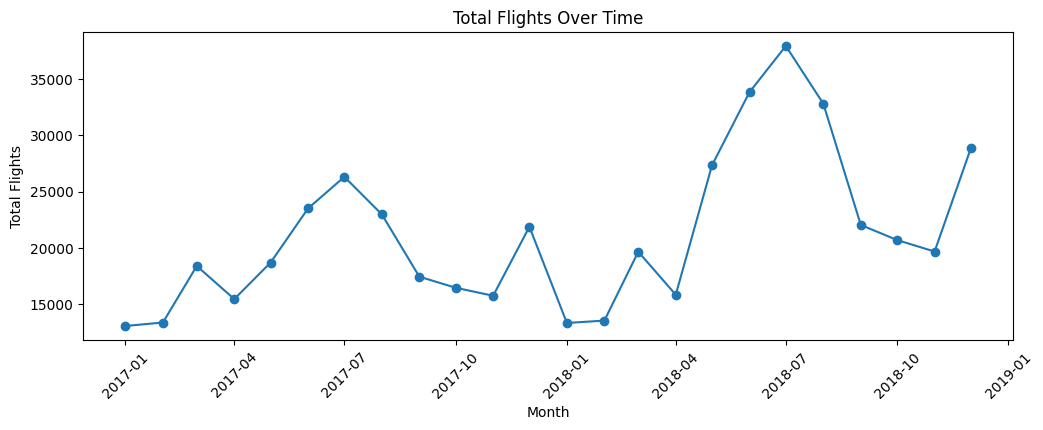

In [114]:
#ploting total flights:
plt.figure(figsize=(12, 4))
plt.plot(monthly_activity["activity_date"], monthly_activity["total_flights"], marker="o")

plt.title("Total Flights Over Time")
plt.xlabel("Month")
plt.ylabel("Total Flights")
plt.xticks(rotation=45)
plt.show()

Observation:
Total flight activity shows a clear seasonal pattern, with higher flight volumes around the middle of the year. The peak is especially strong in 2018, where flights rise sharply from April and reach the highest level around June–July before declining again. This suggests that customer activity is not uniform across months, so churn analysis should account for seasonality. A customer being inactive in an off-season month may not mean the same thing as being inactive during their usual active season.

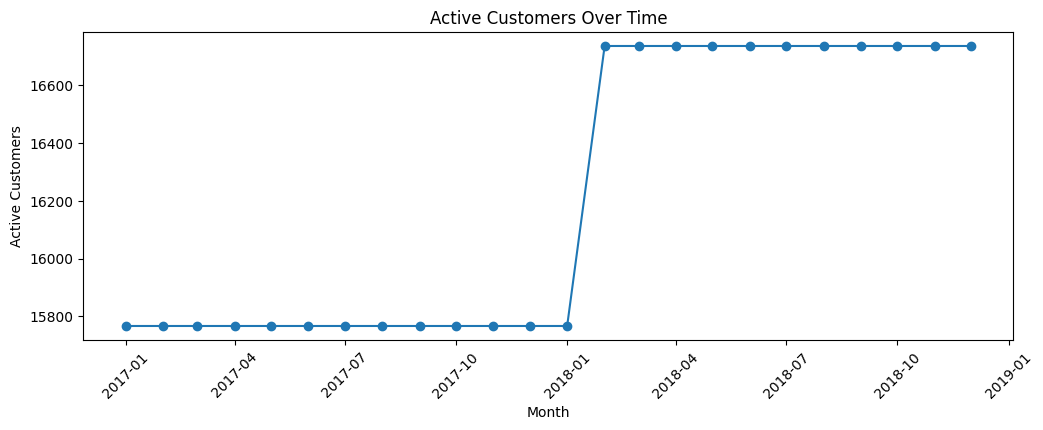

In [115]:
#plotting active customers:
plt.figure(figsize=(12, 4))
plt.plot(monthly_activity["activity_date"], monthly_activity["active_customers"], marker="o")

plt.title("Active Customers Over Time")
plt.xlabel("Month")
plt.ylabel("Active Customers")
plt.xticks(rotation=45)
plt.show()

Observation:
The number of customers present in the monthly activity data is stable throughout 2017, then increases sharply in early 2018 and remains stable afterwards. This jump aligns with the 2018 Promotion cohort, where 971 customers appear from Feb 2018 onward. Therefore, this plot reflects dataset/customer coverage expansion rather than a sudden increase in actual flying activity.

In [116]:
#true active customers
monthly_true_activity = (
    df_monthly
    .groupby("activity_date")
    .agg(
        customers_present=("loyalty_number", "nunique"),
        active_flyers=("total_flights", lambda x: (x > 0).sum()),
        total_flights=("total_flights", "sum")
    )
    .reset_index()
)

monthly_true_activity["active_flyer_rate"] = (
    monthly_true_activity["active_flyers"] / monthly_true_activity["customers_present"] * 100
).round(2)

display(monthly_true_activity)

,activity_date,customers_present,active_flyers,total_flights,active_flyer_rate
0,2017-01-01,15766,6046,13059,38.35
1,2017-02-01,15766,6217,13368,39.43
2,2017-03-01,15766,6654,18391,42.20
3,2017-04-01,15766,6390,15449,40.53
4,2017-05-01,15766,6755,18690,42.85
5,2017-06-01,15766,6888,23504,43.69
6,2017-07-01,15766,7397,26312,46.92
7,2017-08-01,15766,7072,22976,44.86
8,2017-09-01,15766,6802,17439,43.14
9,2017-10-01,15766,6826,16458,43.30


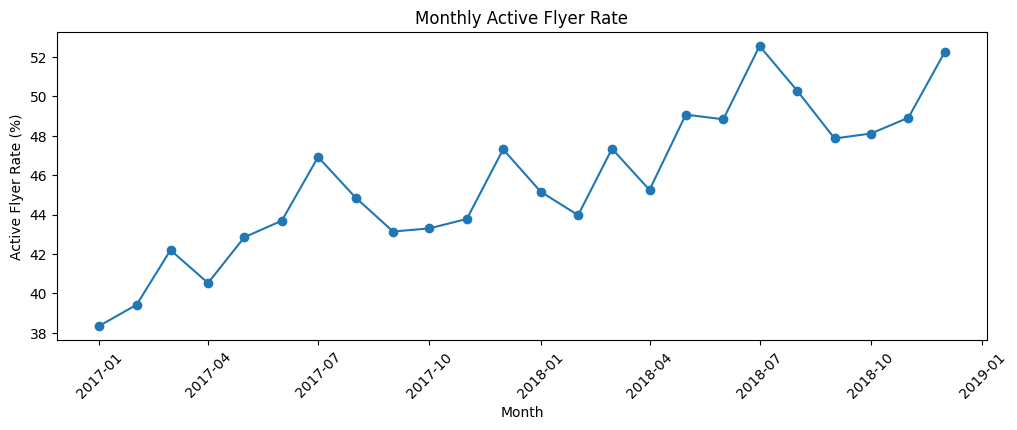

In [117]:
#plotting active flyer rate:
plt.figure(figsize=(12, 4))
plt.plot(monthly_true_activity["activity_date"], monthly_true_activity["active_flyer_rate"], marker="o")

plt.title("Monthly Active Flyer Rate")
plt.xlabel("Month")
plt.ylabel("Active Flyer Rate (%)")
plt.xticks(rotation=45)
plt.show()

Observation:
The monthly active flyer rate increases from around 38–39% in early 2017 to above 50% in parts of 2018. This suggests that customer engagement improved over the observation period, especially during 2018. The pattern also confirms strong seasonality, with higher active flyer rates around mid-year months. For churn modelling, this means inactivity should be interpreted relative to the month/season, not as a fixed rule across the whole year.

In [118]:
#redemption behavior
customer_redemption = (
    df_monthly
    .groupby("loyalty_number")
    .agg(
        total_points_redeemed=("points_redeemed", "sum"),
        redemption_months=("points_redeemed", lambda x: (x > 0).sum()),
        total_points_accumulated=("points_accumulated", "sum"),
        active_months=("total_flights", lambda x: (x > 0).sum())
    )
    .reset_index()
)

customer_redemption["has_redeemed"] = customer_redemption["total_points_redeemed"] > 0

print("Customers who redeemed at least once:")
print(customer_redemption["has_redeemed"].value_counts())
print(customer_redemption["has_redeemed"].value_counts(normalize=True).round(3) * 100)

display(customer_redemption.head())

Customers who redeemed at least once:
has_redeemed
True     11487
False     5250
Name: count, dtype: int64
has_redeemed
True     68.6
False    31.4
Name: proportion, dtype: float64


,loyalty_number,total_points_redeemed,redemption_months,total_points_accumulated,active_months,has_redeemed
0,100018,1513,3,81190.0,18,True
1,100102,1195,2,68918.0,17,True
2,100140,593,1,72856.0,17,True
3,100214,861,2,38236.0,9,True
4,100272,1007,2,54997.0,13,True


Observation:
At the monthly level, points redemption is very sparse, with most customer-month records showing zero redemption. However, at the customer level, 68.6% of customers redeemed points at least once during the observation period, while 31.4% never redeemed. This suggests that redemption is not absent, but infrequent. Therefore, redemption behavior should be studied at the customer level instead of treating monthly non-redemption as disengagement.

In [119]:
#finding points collectors
customer_redemption["redemption_rate"] = (
    customer_redemption["total_points_redeemed"] /
    customer_redemption["total_points_accumulated"].replace(0, np.nan)
)

customer_redemption["redemption_rate"] = customer_redemption["redemption_rate"].fillna(0)

display(customer_redemption["redemption_rate"].describe())

,redemption_rate
count,16737.000000
mean,0.016147
std,0.025660
min,0.000000
25%,0.000000
50%,0.011838
75%,0.023417
max,1.194352


In [120]:
points_collectors = customer_redemption[
    (customer_redemption["total_points_accumulated"] > customer_redemption["total_points_accumulated"].median()) &
    (customer_redemption["redemption_rate"] < 0.02)
]

print("Potential points collectors:", points_collectors.shape[0])
print("Share of all customers (%):", round(points_collectors.shape[0] / customer_redemption.shape[0] * 100, 2))

display(points_collectors.sort_values("total_points_accumulated", ascending=False).head(10))

Potential points collectors: 5895
Share of all customers (%): 35.22


,loyalty_number,total_points_redeemed,redemption_months,total_points_accumulated,active_months,has_redeemed,redemption_rate
10987,689839,0,0,268287.0,8,False,0.000000
14790,893866,1201,2,252960.0,9,True,0.004748
7453,500248,0,0,238120.5,9,False,0.000000
613,133324,892,2,233815.5,9,True,0.003815
6884,471015,772,2,232176.0,9,True,0.003325
5289,385092,418,1,231432.0,8,True,0.001806
1867,201273,1092,2,225346.5,8,True,0.004846
2028,208961,900,2,225282.0,8,True,0.003995
8478,556492,543,1,224673.0,9,True,0.002417
11412,712114,503,1,220048.5,8,True,0.002286


Observation:
A large group of customers appear to accumulate points without redeeming much. Around 35.22% of customers have above-median accumulated points but a redemption rate below 2%, making “Points Collectors” a meaningful behavioral segment. The redemption rate also exceeds 1 for some customers, which likely indicates that they redeemed points accumulated before the 2017–2018 activity window. Therefore, redemption rate should be interpreted as an observed-window metric, not a complete lifetime redemption ratio.

In [121]:
#inspecting high redemption-rate anomaly
high_redemption_rate = customer_redemption[
    customer_redemption["redemption_rate"] > 1
].sort_values("redemption_rate", ascending=False)

print("Customers with redemption_rate > 1:", high_redemption_rate.shape[0])

display(high_redemption_rate.head(10))

Customers with redemption_rate > 1: 2


,loyalty_number,total_points_redeemed,redemption_months,total_points_accumulated,active_months,has_redeemed,redemption_rate
15797,949612,719,1,602.0,1,True,1.194352
2025,208668,542,1,513.0,1,True,1.056530


In [122]:
print("Share of customers with redemption_rate > 1 (%):")
print(round(high_redemption_rate.shape[0] / customer_redemption.shape[0] * 100, 2))

Share of customers with redemption_rate > 1 (%):
0.01


Only 2 customers have redemption_rate above 1, meaning they redeemed more points than they accumulated within the 2017–2018 activity window. This is likely because the dataset does not include points

In [123]:
# Checking if Points Collectors are valuable?
# Create one row per customer with profile information

customer_profile = (
    df_monthly
    .groupby("loyalty_number")
    .agg(
        clv=("clv", "first"),
        loyalty_card=("loyalty_card", "first"),
        province=("province", "first"),
        city=("city", "first"),
        gender=("gender", "first"),
        education=("education", "first"),
        salary=("salary", "first"),
        enrollment_type=("enrollment_type", "first"),
        formal_churn=("formal_churn", "first")
    )
    .reset_index()
)

print("Customer profile shape:", customer_profile.shape)
display(customer_profile.head())

Customer profile shape: (16737, 10)


,loyalty_number,clv,loyalty_card,province,city,gender,education,salary,enrollment_type,formal_churn
0,100018,7919.20,Aurora,Alberta,Edmonton,Female,Bachelor,92552.0,Standard,0
1,100102,2887.74,Nova,Ontario,Toronto,Male,College,NaN,Standard,0
2,100140,2838.07,Nova,British Columbia,Dawson Creek,Female,College,NaN,Standard,0
3,100214,4170.57,Star,British Columbia,Vancouver,Male,Bachelor,63253.0,Standard,0
4,100272,6622.05,Star,Ontario,Toronto,Female,Bachelor,91163.0,Standard,0


In [124]:
# Merge redemption behavior with profile
customer_redemption_profile = customer_redemption.merge(
    customer_profile,
    on="loyalty_number",
    how="left"
)

print("Customer redemption profile shape:", customer_redemption_profile.shape)
display(customer_redemption_profile.head())

Customer redemption profile shape: (16737, 16)


,loyalty_number,total_points_redeemed,redemption_months,total_points_accumulated,active_months,has_redeemed,redemption_rate,clv,loyalty_card,province,city,gender,education,salary,enrollment_type,formal_churn
0,100018,1513,3,81190.0,18,True,0.018635,7919.20,Aurora,Alberta,Edmonton,Female,Bachelor,92552.0,Standard,0
1,100102,1195,2,68918.0,17,True,0.017339,2887.74,Nova,Ontario,Toronto,Male,College,NaN,Standard,0
2,100140,593,1,72856.0,17,True,0.008139,2838.07,Nova,British Columbia,Dawson Creek,Female,College,NaN,Standard,0
3,100214,861,2,38236.0,9,True,0.022518,4170.57,Star,British Columbia,Vancouver,Male,Bachelor,63253.0,Standard,0
4,100272,1007,2,54997.0,13,True,0.018310,6622.05,Star,Ontario,Toronto,Female,Bachelor,91163.0,Standard,0


In [125]:
# Creating Points Collector flag
median_points = customer_redemption_profile["total_points_accumulated"].median()

customer_redemption_profile["points_collector_flag"] = (
    (customer_redemption_profile["total_points_accumulated"] > median_points) &
    (customer_redemption_profile["redemption_rate"] < 0.02)
).astype(int)

print("Median accumulated points:", median_points)

print("\nPoints collector distribution:")
print(customer_redemption_profile["points_collector_flag"].value_counts())

print("\nPoints collector distribution (%):")
print(customer_redemption_profile["points_collector_flag"].value_counts(normalize=True).round(3) * 100)

Median accumulated points: 49885.0

Points collector distribution:
points_collector_flag
0    10842
1     5895
Name: count, dtype: int64

Points collector distribution (%):
points_collector_flag
0    64.8
1    35.2
Name: proportion, dtype: float64


In [126]:
# Comparing Points Collectors vs others
points_collector_summary = (
    customer_redemption_profile
    .groupby("points_collector_flag")
    .agg(
        customer_count=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        avg_points_accumulated=("total_points_accumulated", "mean"),
        avg_points_redeemed=("total_points_redeemed", "mean"),
        avg_redemption_rate=("redemption_rate", "mean"),
        formal_churn_rate=("formal_churn", "mean")
    )
    .round(3)
)

display(points_collector_summary)

,customer_count,avg_clv,median_clv,avg_points_accumulated,avg_points_redeemed,avg_redemption_rate,formal_churn_rate
points_collector_flag,,,,,,,
0,10842,8020.346,5750.54,33853.303,809.241,0.020,0.176
1,5895,7931.056,5830.56,72860.302,598.266,0.009,0.026


Observation:
Points Collectors form a large segment of the customer base, covering 35.2% of customers. They accumulate more than twice as many points as other customers on average, but redeem fewer points and have a lower redemption rate. Interestingly, their formal churn rate is much lower than other customers. This suggests that Points Collectors are not necessarily immediate churn risks; instead, they represent a loyalty engagement opportunity. If their travel activity later declines, their unused points balance can become an important retention trigger.

In [127]:
# Summarizing customer value and churn by loyalty card tier

loyalty_card_summary = (
    customer_profile
    .groupby("loyalty_card")
    .agg(
        customer_count=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        formal_churn_rate=("formal_churn", "mean"),
        avg_salary=("salary", "mean")
    )
    .round(2)
    .sort_values("avg_clv", ascending=False)
)

display(loyalty_card_summary)

,customer_count,avg_clv,median_clv,formal_churn_rate,avg_salary
loyalty_card,,,,,
Aurora,3429,10672.69,8140.00,0.13,78848.70
Nova,5671,8045.62,5799.06,0.13,78756.42
Star,7637,6741.76,4786.89,0.12,79819.08


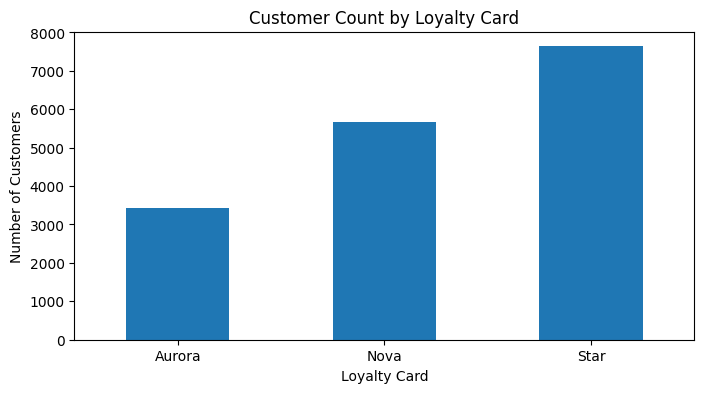

In [128]:
# Plotting number of customers by loyalty card tier

loyalty_card_summary["customer_count"].plot(kind="bar", figsize=(8, 4))

plt.title("Customer Count by Loyalty Card")
plt.xlabel("Loyalty Card")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

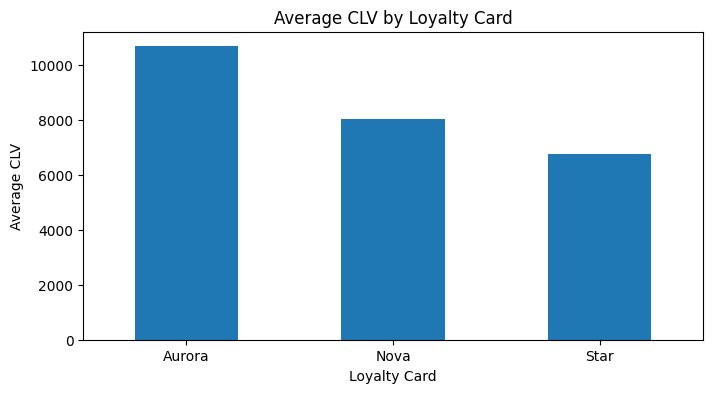

In [129]:
# Plotting average CLV by loyalty card tier

loyalty_card_summary["avg_clv"].plot(kind="bar", figsize=(8, 4))

plt.title("Average CLV by Loyalty Card")
plt.xlabel("Loyalty Card")
plt.ylabel("Average CLV")
plt.xticks(rotation=0)
plt.show()

Observation:
Loyalty card tiers show a clear value difference. Aurora customers have the highest average CLV, followed by Nova and Star, while Star has the largest customer base. However, formal churn rates are almost similar across all three tiers. This suggests that loyalty card tier is more useful for estimating customer value than for directly identifying formal churn risk. For retention planning, Aurora customers may deserve higher priority when at risk, but churn risk still needs to be determined from behavior, not tier alone.

,clv
count,16737.000000
mean,7988.896536
std,6860.982280
min,1898.010000
25%,3980.840000
50%,5780.180000
75%,8940.580000
max,83325.380000


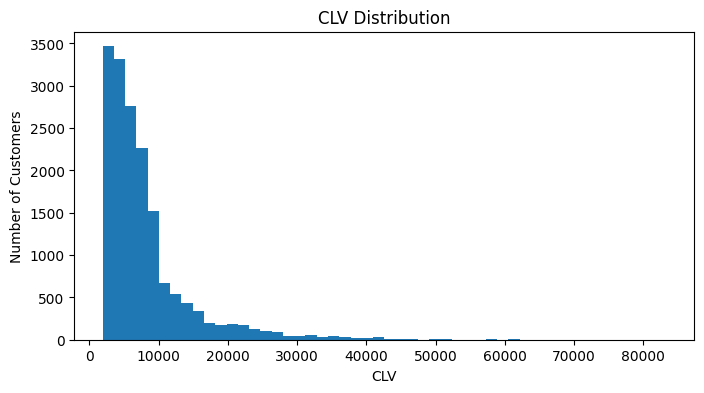

In [130]:
# Checking CLV distribution and possible outliers

display(customer_profile["clv"].describe())

plt.figure(figsize=(8, 4))
plt.hist(customer_profile["clv"], bins=50)

plt.title("CLV Distribution")
plt.xlabel("CLV")
plt.ylabel("Number of Customers")
plt.show()

In [131]:
# Checking very high CLV customers

high_clv_cutoff = customer_profile["clv"].quantile(0.99)

print("99th percentile CLV:", high_clv_cutoff)

high_clv_customers = customer_profile[customer_profile["clv"] >= high_clv_cutoff]

print("Number of customers above 99th percentile:", high_clv_customers.shape[0])

display(
    high_clv_customers
    .sort_values("clv", ascending=False)
    .head(10)
)

99th percentile CLV: 35928.64319999998
Number of customers above 99th percentile: 168


,loyalty_number,clv,loyalty_card,province,city,gender,education,salary,enrollment_type,formal_churn
10297,652627,83325.38,Star,Manitoba,Winnipeg,Female,Bachelor,75049.0,Standard,1
9611,615459,83325.38,Star,Quebec,Montreal,Male,Bachelor,75049.0,2018 Promotion,1
13888,844145,74228.52,Nova,Ontario,Toronto,Female,College,NaN,Standard,1
12631,776187,74228.52,Star,British Columbia,Vancouver,Male,College,NaN,Standard,0
9156,592003,73225.96,Aurora,New Brunswick,Fredericton,Male,Bachelor,60845.0,2018 Promotion,0
12468,767366,73225.96,Aurora,Quebec,Montreal,Female,Bachelor,60845.0,Standard,1
13776,838263,67907.27,Aurora,Nova Scotia,Halifax,Male,Bachelor,89210.0,Standard,0
10820,680886,67907.27,Star,Saskatchewan,Regina,Female,Bachelor,89210.0,Standard,0
1465,179870,66025.75,Aurora,Quebec,Montreal,Female,Bachelor,56406.0,Standard,0
7357,495253,66025.75,Nova,British Columbia,Whistler,Male,Bachelor,56406.0,Standard,0


Observation:
CLV is highly right-skewed. Most customers have relatively moderate CLV, while a small group of customers have extremely high values. The 99th percentile CLV is around 35,929, and 168 customers lie above this cutoff. These high-CLV customers are important for retention prioritization because losing even a small number of them can represent a large value loss. Since the distribution is skewed, later modelling should avoid relying on raw CLV alone; percentile-based value tiers or log-transformed CLV may be more stable.

In [132]:
# Comparing CLV between formally churned and non-churned customers

churn_clv_summary = (
    customer_profile
    .groupby("formal_churn")
    .agg(
        customer_count=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        p90_clv=("clv", lambda x: x.quantile(0.90)),
        p99_clv=("clv", lambda x: x.quantile(0.99))
    )
    .round(2)
)

display(churn_clv_summary)

,customer_count,avg_clv,median_clv,p90_clv,p99_clv
formal_churn,,,,,
0,14670,7968.76,5776.34,15278.17,36057.54
1,2067,8131.78,5793.16,15944.36,33473.35


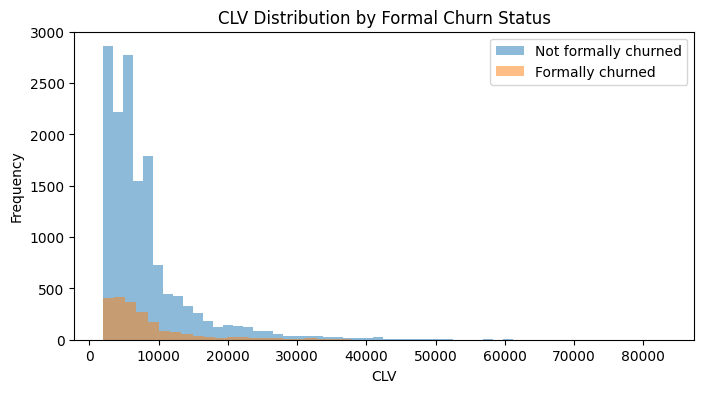

In [133]:
# Plotting CLV distribution by formal churn status

plt.figure(figsize=(8, 4))

customer_profile[customer_profile["formal_churn"] == 0]["clv"].plot(
    kind="hist", bins=50, alpha=0.5, label="Not formally churned"
)

customer_profile[customer_profile["formal_churn"] == 1]["clv"].plot(
    kind="hist", bins=50, alpha=0.5, label="Formally churned"
)

plt.title("CLV Distribution by Formal Churn Status")
plt.xlabel("CLV")
plt.legend()
plt.show()

Observation:
Formal churn does not appear to be strongly separated by CLV. Churned and non-churned customers have very similar average and median CLV values, and both groups show a right-skewed distribution. This suggests that customer value alone is not enough to identify churn risk. A high-value customer may still churn, so churn prediction should combine value with behavioral activity patterns such as flights, inactivity, points behavior, and recent decline.

In [134]:
# Comparing formal churn rate across loyalty card tiers

churn_by_card = (
    customer_profile
    .groupby("loyalty_card")
    .agg(
        customers=("loyalty_number", "count"),
        churn_rate=("formal_churn", "mean"),
        avg_clv=("clv", "mean")
    )
    .round(3)
    .sort_values("churn_rate", ascending=False)
)

display(churn_by_card)

,customers,churn_rate,avg_clv
loyalty_card,,,
Aurora,3429,0.131,10672.686
Nova,5671,0.126,8045.616
Star,7637,0.118,6741.761


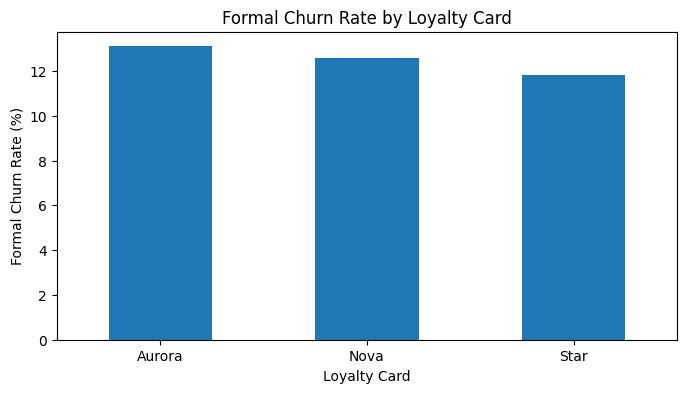

In [135]:
# Plotting formal churn rate by loyalty card tier

(churn_by_card["churn_rate"] * 100).plot(kind="bar", figsize=(8, 4))

plt.title("Formal Churn Rate by Loyalty Card")
plt.xlabel("Loyalty Card")
plt.ylabel("Formal Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Observation:
Formal churn rates are fairly similar across loyalty card tiers, ranging from 11.8% for Star to 13.1% for Aurora. Although Aurora customers have much higher average CLV, they do not show meaningfully lower churn. This supports the idea that loyalty tier should be used for value prioritization, while churn risk should be estimated from behavioral activity patterns.

In [136]:
# Comparing customer count, CLV, and formal churn by enrollment type

enrollment_summary = (
    customer_profile
    .groupby("enrollment_type")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        churn_rate=("formal_churn", "mean")
    )
    .round(3)
    .sort_values("churn_rate", ascending=False)
)

display(enrollment_summary)

,customers,avg_clv,median_clv,churn_rate
enrollment_type,,,,
Standard,15766,7985.348,5768.83,0.124
2018 Promotion,971,8046.511,5926.39,0.118


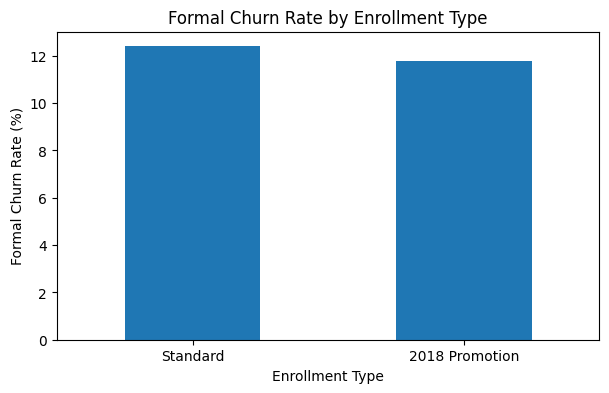

In [137]:
# Plotting formal churn rate by enrollment type

(enrollment_summary["churn_rate"] * 100).plot(kind="bar", figsize=(7, 4))

plt.title("Formal Churn Rate by Enrollment Type")
plt.xlabel("Enrollment Type")
plt.ylabel("Formal Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Observation:
The 2018 Promotion cohort has CLV and formal churn rate very similar to standard customers. This suggests that the promotion did not obviously bring in lower-value or higher-churn customers. However, these customers have only 11 months of observed flight activity, so they should still be handled carefully while creating behavioral churn and trend-based features.

In [138]:
# Summarizing customers, CLV, and churn by province

province_summary = (
    customer_profile
    .groupby("province")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        churn_rate=("formal_churn", "mean")
    )
    .round(3)
    .sort_values("customers", ascending=False)
)

display(province_summary)

,customers,avg_clv,median_clv,churn_rate
province,,,,
Ontario,5404,7913.752,5765.140,0.125
British Columbia,4409,7993.727,5815.260,0.118
Quebec,3300,8160.956,5809.095,0.125
Alberta,969,7752.789,5759.910,0.126
Manitoba,658,8066.556,5653.205,0.152
New Brunswick,636,8154.183,5576.390,0.105
Nova Scotia,518,7983.305,5830.015,0.112
Saskatchewan,409,8076.374,5706.960,0.122
Newfoundland,258,8025.080,5511.185,0.147


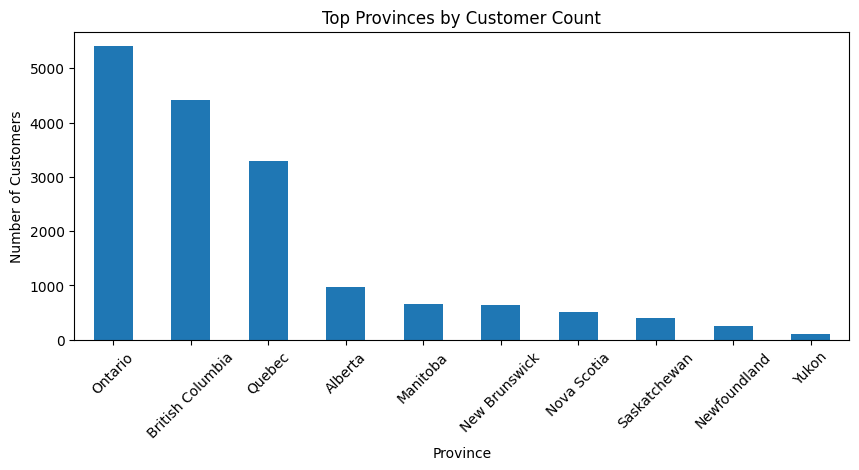

In [139]:
# Plotting top provinces by customer count

province_summary["customers"].head(10).plot(kind="bar", figsize=(10, 4))

plt.title("Top Provinces by Customer Count")
plt.xlabel("Province")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

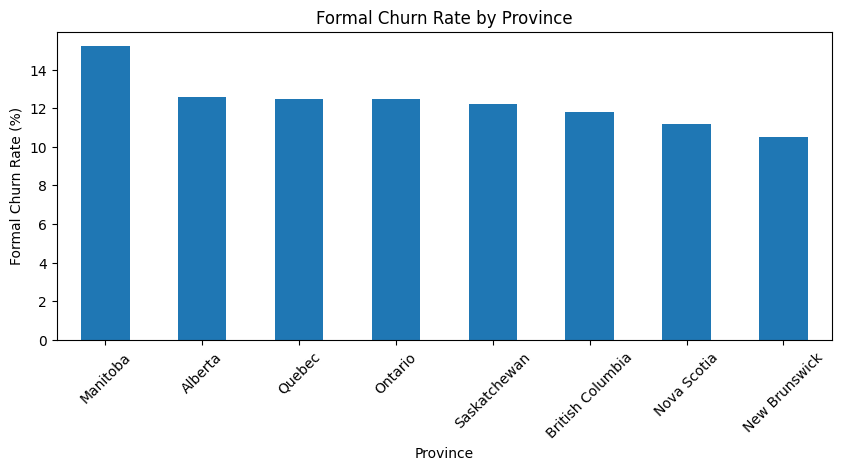

In [140]:
# Plotting formal churn rate for provinces with at least 300 customers

province_churn_plot = province_summary[province_summary["customers"] >= 300].sort_values("churn_rate", ascending=False)

(province_churn_plot["churn_rate"] * 100).plot(kind="bar", figsize=(10, 4))

plt.title("Formal Churn Rate by Province")
plt.xlabel("Province")
plt.ylabel("Formal Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [141]:
# Checking how many customers have missing salary

customer_profile["salary_missing"] = customer_profile["salary"].isnull().astype(int)

print("Salary missing distribution:")
print(customer_profile["salary_missing"].value_counts())

print("\nSalary missing distribution (%):")
print(customer_profile["salary_missing"].value_counts(normalize=True).round(3) * 100)

Salary missing distribution:
salary_missing
0    12499
1     4238
Name: count, dtype: int64

Salary missing distribution (%):
salary_missing
0    74.7
1    25.3
Name: proportion, dtype: float64


In [142]:
# Checking salary missingness by education

salary_missing_by_education = (
    customer_profile
    .groupby("education")
    .agg(
        customers=("loyalty_number", "count"),
        salary_missing_rate=("salary_missing", "mean"),
        avg_clv=("clv", "mean"),
        formal_churn_rate=("formal_churn", "mean")
    )
    .round(3)
    .sort_values("salary_missing_rate", ascending=False)
)

display(salary_missing_by_education)

,customers,salary_missing_rate,avg_clv,formal_churn_rate
education,,,,
College,4238,1.0,7594.572,0.124
Bachelor,10475,0.0,8206.991,0.123
Doctor,734,0.0,7832.920,0.131
High School or Below,782,0.0,7707.080,0.119
Master,508,0.0,7440.625,0.128


In [143]:
# Checking salary missingness by enrollment type

salary_missing_by_enrollment = (
    customer_profile
    .groupby("enrollment_type")
    .agg(
        customers=("loyalty_number", "count"),
        salary_missing_rate=("salary_missing", "mean"),
        avg_clv=("clv", "mean"),
        formal_churn_rate=("formal_churn", "mean")
    )
    .round(3)
)

display(salary_missing_by_enrollment)

,customers,salary_missing_rate,avg_clv,formal_churn_rate
enrollment_type,,,,
2018 Promotion,971,0.245,8046.511,0.118
Standard,15766,0.254,7985.348,0.124


Observation:
Salary is missing for 25.3% of customers, but the missingness is not random. All customers with College education have missing salary, while other education categories have salary available. Therefore, salary should not be used directly without handling missingness, and rows with missing salary should not be dropped because that would remove the entire College segment. A salary_missing flag should be retained for modelling, and salary can later be imputed only after considering education-level patterns.

In [144]:
# Comparing customer value and churn across education levels

education_summary = (
    customer_profile
    .groupby("education")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        formal_churn_rate=("formal_churn", "mean"),
        salary_missing_rate=("salary_missing", "mean")
    )
    .round(3)
    .sort_values("avg_clv", ascending=False)
)

display(education_summary)

,customers,avg_clv,median_clv,formal_churn_rate,salary_missing_rate
education,,,,,
Bachelor,10475,8206.991,5866.070,0.123,0.0
Doctor,734,7832.920,5676.785,0.131,0.0
High School or Below,782,7707.080,5258.925,0.119,0.0
College,4238,7594.572,5577.130,0.124,1.0
Master,508,7440.625,5095.080,0.128,0.0


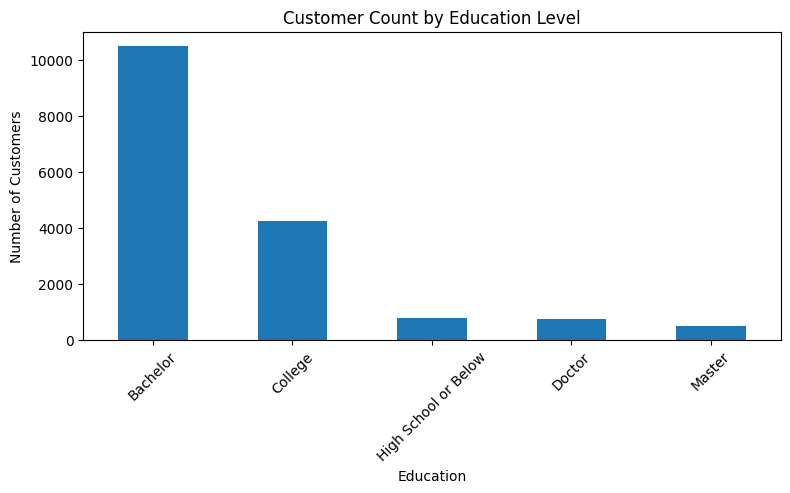

In [145]:
# Plotting customer count by education level

education_summary["customers"].sort_values(ascending=False).plot(kind="bar", figsize=(9, 4))

plt.title("Customer Count by Education Level")
plt.xlabel("Education")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

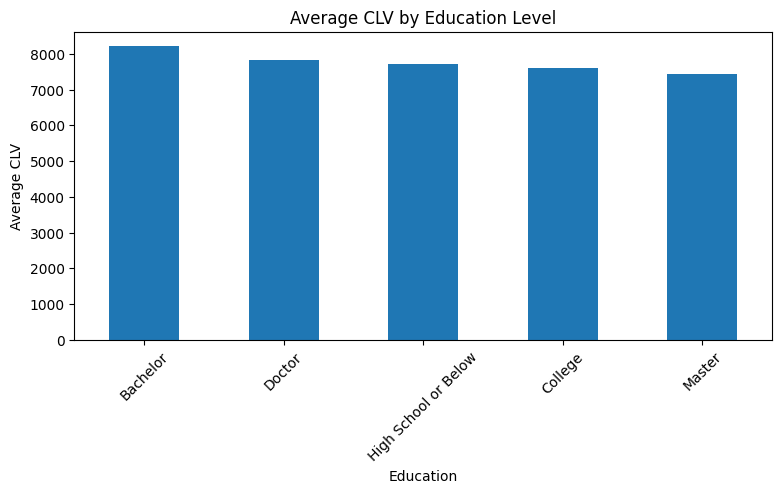

In [146]:
# Plotting average CLV by education level

education_summary["avg_clv"].plot(kind="bar", figsize=(9, 4))

plt.title("Average CLV by Education Level")
plt.xlabel("Education")
plt.ylabel("Average CLV")
plt.xticks(rotation=45)
plt.show()

Observation:
Most customers have Bachelor or College education, while Master, Doctor, and High School or Below groups are much smaller. Average CLV varies slightly across education levels, with Bachelor customers having the highest average CLV, but formal churn rates remain fairly similar across groups. Education appears more useful as a demographic/profile feature than as a direct churn indicator. The main data-quality issue is that salary is missing for all College customers, so salary must be handled carefully during modelling.

In [147]:
# Finding top cities by customer count, CLV, and churn

city_summary = (
    customer_profile
    .groupby("city")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        churn_rate=("formal_churn", "mean")
    )
    .round(3)
    .sort_values("customers", ascending=False)
)

display(city_summary.head(15))

,customers,avg_clv,churn_rate
city,,,
Toronto,3351,7862.179,0.123
Vancouver,2582,7846.915,0.119
Montreal,2059,8318.434,0.127
Winnipeg,658,8066.556,0.152
Whistler,582,8769.008,0.119
Halifax,518,7983.305,0.112
Ottawa,509,8033.919,0.106
Trenton,486,7787.730,0.138
Edmonton,486,7920.366,0.123


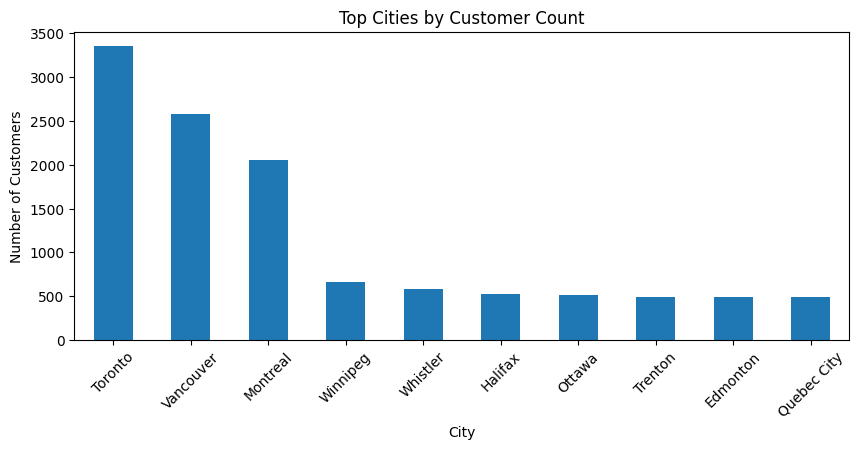

In [148]:
# Plotting top 10 cities by customer count

city_summary["customers"].head(10).plot(kind="bar", figsize=(10, 4))

plt.title("Top Cities by Customer Count")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

Observation:
Customer distribution is concentrated in a few major cities, especially Toronto, Vancouver, and Montreal. Some smaller cities such as Winnipeg, Trenton, Kingston, and Tremblant show relatively higher formal churn rates, but city-level churn should be interpreted carefully because smaller customer bases can make rates unstable. City is useful for dashboard filtering and regional campaign planning, but behavioral activity patterns are likely more important for churn detection.

In [149]:
# Creating customer-level activity metrics

customer_activity = (
    df_monthly
    .groupby("loyalty_number")
    .agg(
        months_present=("activity_date", "nunique"),
        total_flights=("total_flights", "sum"),
        active_months=("total_flights", lambda x: (x > 0).sum()),
        total_distance=("distance", "sum"),
        total_points_accumulated=("points_accumulated", "sum"),
        total_points_redeemed=("points_redeemed", "sum")
    )
    .reset_index()
)

customer_activity["inactive_months"] = (
    customer_activity["months_present"] - customer_activity["active_months"]
)

customer_activity["active_month_rate"] = (
    customer_activity["active_months"] / customer_activity["months_present"]
)

customer_activity["avg_flights_per_active_month"] = (
    customer_activity["total_flights"] /
    customer_activity["active_months"].replace(0, np.nan)
).fillna(0)

display(customer_activity.head())

,loyalty_number,months_present,total_flights,active_months,total_distance,total_points_accumulated,total_points_redeemed,inactive_months,active_month_rate,avg_flights_per_active_month
0,100018,24,46,18,81190,81190.0,1513,6,0.750000,2.555556
1,100102,24,51,17,68918,68918.0,1195,7,0.708333,3.000000
2,100140,24,47,17,72856,72856.0,593,7,0.708333,2.764706
3,100214,24,22,9,38236,38236.0,861,15,0.375000,2.444444
4,100272,24,37,13,54997,54997.0,1007,11,0.541667,2.846154


In [150]:
# Summarizing customer-level activity metrics

display(
    customer_activity[
        ["months_present", "total_flights", "active_months", "inactive_months",
         "active_month_rate", "avg_flights_per_active_month", "total_distance"]
    ].describe()
)

,months_present,total_flights,active_months,inactive_months,active_month_rate,avg_flights_per_active_month,total_distance
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000
mean,23.245803,30.400191,10.633507,12.612296,0.459050,2.745871,45579.359921
std,3.039129,16.865558,5.686668,5.828888,0.234931,1.741524,26092.338663
min,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,20.000000,6.000000,8.000000,0.333333,2.307692,28495.000000
50%,24.000000,34.000000,12.000000,11.000000,0.541667,2.647059,49445.000000
75%,24.000000,42.000000,15.000000,16.000000,0.625000,3.000000,62911.000000
max,24.000000,106.000000,24.000000,24.000000,1.000000,24.000000,178858.000000


Observation:
Customer flight engagement varies widely. The average customer is active in around 10.6 months and inactive in around 12.6 months, while the median customer is active in 12 out of 24 months. This confirms that inactivity is common in airline loyalty behavior and should not be treated as churn unless it is sustained or unusual for that customer. The wide range in active months also suggests that segmentation should consider engagement frequency, not only total flights or CLV.

In [151]:
# Finding customers with no flights and customers active in every observed month

never_flyers = customer_activity[customer_activity["total_flights"] == 0]
always_active = customer_activity[
    customer_activity["active_months"] == customer_activity["months_present"]
]

print("Never flyers:", never_flyers.shape[0])
print("Always active customers:", always_active.shape[0])

print("\nNever flyers share (%):", round(never_flyers.shape[0] / customer_activity.shape[0] * 100, 2))
print("Always active share (%):", round(always_active.shape[0] / customer_activity.shape[0] * 100, 2))

Never flyers: 1570
Always active customers: 2

Never flyers share (%): 9.38
Always active share (%): 0.01


In [152]:
# Adding profile information to inspect extreme activity groups

customer_activity_profile = customer_activity.merge(
    customer_profile,
    on="loyalty_number",
    how="left"
)

never_flyers_profile = customer_activity_profile[
    customer_activity_profile["total_flights"] == 0
]

always_active_profile = customer_activity_profile[
    customer_activity_profile["active_months"] == customer_activity_profile["months_present"]
]

display(
    never_flyers_profile
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        churn_rate=("formal_churn", "mean")
    )
)

display(
    always_active_profile
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        churn_rate=("formal_churn", "mean")
    )
)

,loyalty_number,clv,formal_churn
customers,1570.0,NaN,NaN
avg_clv,NaN,8360.820287,NaN
median_clv,NaN,5907.950000,NaN
churn_rate,NaN,NaN,0.605732


,loyalty_number,clv,formal_churn
customers,2.0,NaN,NaN
avg_clv,NaN,6760.645,NaN
median_clv,NaN,6760.645,NaN
churn_rate,NaN,NaN,0.0


Observation:
Around 9.38% of customers recorded no flights during the observed activity period. This group has a very high formal churn rate of around 60.6%, much higher than the overall formal churn rate of around 12%. This confirms that sustained inactivity is a strong churn signal, while one or two inactive months are not enough to define churn. In contrast, only 2 customers were active in every observed month, so “always active” customers are too rare to treat as a separate segment.

In [153]:
# Creating a cleaner summary for extreme activity groups

extreme_activity_summary = pd.DataFrame({
    "group": ["Never Flyers", "Always Active"],
    "customers": [never_flyers_profile.shape[0], always_active_profile.shape[0]],
    "avg_clv": [never_flyers_profile["clv"].mean(), always_active_profile["clv"].mean()],
    "median_clv": [never_flyers_profile["clv"].median(), always_active_profile["clv"].median()],
    "formal_churn_rate": [never_flyers_profile["formal_churn"].mean(), always_active_profile["formal_churn"].mean()]
}).round(3)

display(extreme_activity_summary)

,group,customers,avg_clv,median_clv,formal_churn_rate
0,Never Flyers,1570,8360.820,5907.950,0.606
1,Always Active,2,6760.645,6760.645,0.000


In [154]:
# Grouping customers by number of active months and checking churn rate

active_month_churn = (
    customer_activity_profile
    .groupby("active_months")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        churn_rate=("formal_churn", "mean")
    )
    .round(3)
    .reset_index()
)

display(active_month_churn)

,active_months,customers,avg_clv,churn_rate
0,0,1570,8360.820,0.606
1,1,409,7828.632,0.196
2,2,423,8541.433,0.227
3,3,448,7982.218,0.248
4,4,491,8085.802,0.348
5,5,499,7876.156,0.325
6,6,527,7623.550,0.279
7,7,476,8462.878,0.185
8,8,445,7302.776,0.094
9,9,478,7383.159,0.090


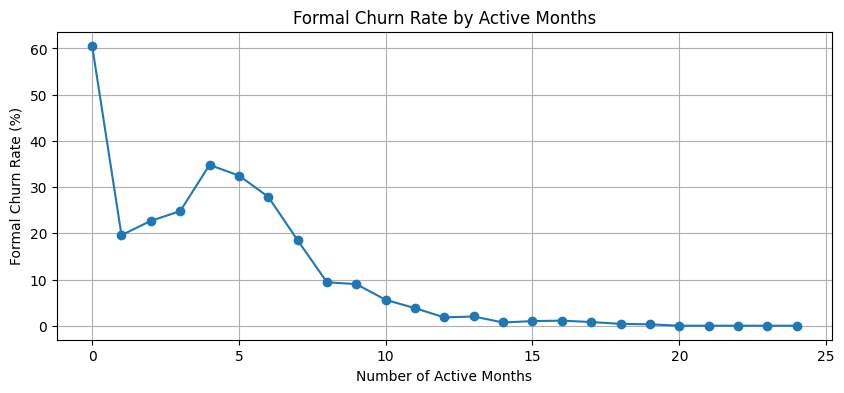

In [155]:
# Plotting churn rate by active months

plt.figure(figsize=(10, 4))
plt.plot(active_month_churn["active_months"], active_month_churn["churn_rate"] * 100, marker="o")

plt.title("Formal Churn Rate by Active Months")
plt.xlabel("Number of Active Months")
plt.ylabel("Formal Churn Rate (%)")
plt.grid(True)
plt.show()

Observation:
Formal churn rate shows a strong relationship with customer activity frequency. Customers with zero active months have a churn rate of around 60.6%, while churn rate drops sharply as the number of active months increases. After around 10–12 active months, formal churn becomes very low. This supports the idea that behavioral activity is a much stronger churn signal than customer profile variables alone. For the final churn model, active months, inactivity duration, and recent activity decline should be key features.

In [156]:
# Grouping customers by inactive months and checking churn rate

inactive_month_churn = (
    customer_activity_profile
    .groupby("inactive_months")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        churn_rate=("formal_churn", "mean")
    )
    .round(3)
    .reset_index()
)

display(inactive_month_churn)

,inactive_months,customers,avg_clv,churn_rate
0,0,2,6760.645,0.000
1,1,11,8828.285,0.000
2,2,49,8556.462,0.020
3,3,159,8117.023,0.006
4,4,286,8277.061,0.024
5,5,525,7768.872,0.051
6,6,741,8187.380,0.038
7,7,1077,7966.338,0.032
8,8,1437,7940.998,0.020
9,9,1646,8272.230,0.014


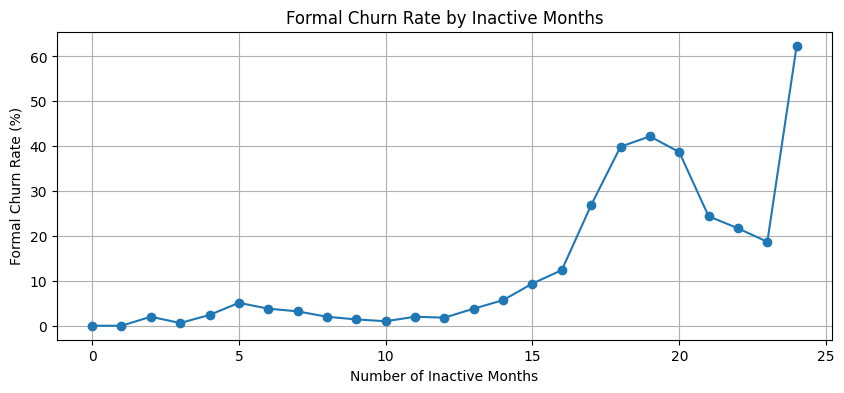

In [157]:
# Plotting churn rate by inactive months

plt.figure(figsize=(10, 4))
plt.plot(inactive_month_churn["inactive_months"], inactive_month_churn["churn_rate"] * 100, marker="o")

plt.title("Formal Churn Rate by Inactive Months")
plt.xlabel("Number of Inactive Months")
plt.ylabel("Formal Churn Rate (%)")
plt.grid(True)
plt.show()

Observation:
Formal churn rate increases sharply when customers have a high number of inactive months. Customers with 17 or more inactive months show much higher churn rates, and customers inactive for all 24 months have a churn rate above 60%. This supports using sustained inactivity as a major behavioral churn signal. However, the relationship is not perfectly smooth, so inactivity should be combined with other signals such as recent activity trend, points behavior, and customer value.

In [158]:
# Creating recent inactivity indicators using the last 3 and last 6 months of data

last_date = df_monthly["activity_date"].max()

last_3_months = pd.date_range(end=last_date, periods=3, freq="MS")
last_6_months = pd.date_range(end=last_date, periods=6, freq="MS")

print("Last date:", last_date)
print("Last 3 months:", list(last_3_months))
print("Last 6 months:", list(last_6_months))

Last date: 2018-12-01 00:00:00
Last 3 months: [Timestamp('2018-10-01 00:00:00'), Timestamp('2018-11-01 00:00:00'), Timestamp('2018-12-01 00:00:00')]
Last 6 months: [Timestamp('2018-07-01 00:00:00'), Timestamp('2018-08-01 00:00:00'), Timestamp('2018-09-01 00:00:00'), Timestamp('2018-10-01 00:00:00'), Timestamp('2018-11-01 00:00:00'), Timestamp('2018-12-01 00:00:00')]


In [ ]:
# Checking customer activity in the last 3 and last 6 months

recent_activity = (
    df_monthly
    .assign(
        is_last_3_months=df_monthly["activity_date"].isin(last_3_months),
        is_last_6_months=df_monthly["activity_date"].isin(last_6_months)
    )
    .groupby("loyalty_number")
    .agg(
        flights_last_3m=("total_flights", lambda x: x[df_monthly.loc[x.index, "activity_date"].isin(last_3_months)].sum()),
        flights_last_6m=("total_flights", lambda x: x[df_monthly.loc[x.index, "activity_date"].isin(last_6_months)].sum()),
        points_accumulated_last_6m=("points_accumulated", lambda x: x[df_monthly.loc[x.index, "activity_date"].isin(last_6_months)].sum()),
        points_redeemed_last_6m=("points_redeemed", lambda x: x[df_monthly.loc[x.index, "activity_date"].isin(last_6_months)].sum())
    )
    .reset_index()
)

recent_activity["inactive_last_3m"] = (recent_activity["flights_last_3m"] == 0).astype(int)
recent_activity["inactive_last_6m"] = (recent_activity["flights_last_6m"] == 0).astype(int)

display(recent_activity.head())

In [ ]:
# Comparing recent inactivity with formal churn

recent_activity_profile = recent_activity.merge(
    customer_profile,
    on="loyalty_number",
    how="left"
)

recent_inactivity_summary = (
    recent_activity_profile
    .groupby(["inactive_last_3m", "inactive_last_6m"])
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        formal_churn_rate=("formal_churn", "mean")
    )
    .round(3)
)

display(recent_inactivity_summary)

Observation:
Recent inactivity is strongly associated with formal churn. Customers who had some flight activity in the last 3–6 months show a very low formal churn rate of around 1.2%. Customers inactive in the last 3 months but not the full 6 months have a higher churn rate of 17.2%. The strongest signal is 6-month inactivity: customers with no flights in the last 6 months have a formal churn rate of 70.6%. This supports using sustained recent inactivity as a key behavioral churn signal rather than relying only on formal cancellation records.

In [ ]:
# Estimating CLV concentration among recently inactive customers

recent_activity_profile["inactive_group"] = np.where(
    recent_activity_profile["inactive_last_6m"] == 1,
    "Inactive last 6 months",
    "Active in last 6 months"
)

clv_inactivity_summary = (
    recent_activity_profile
    .groupby("inactive_group")
    .agg(
        customers=("loyalty_number", "count"),
        total_clv=("clv", "sum"),
        avg_clv=("clv", "mean"),
        formal_churn_rate=("formal_churn", "mean")
    )
    .round(2)
)

clv_inactivity_summary["clv_share_pct"] = (
    clv_inactivity_summary["total_clv"] /
    clv_inactivity_summary["total_clv"].sum() * 100
).round(2)

display(clv_inactivity_summary)

Observation:
Customers inactive in the last 6 months represent 2,469 customers and around 15% of total observed CLV. This group has a very high formal churn rate of around 71%, while customers active in the last 6 months have only around 2% formal churn. Importantly, the inactive group does not have lower value; its average CLV is slightly higher than the active group. This makes recent inactivity a strong candidate for Loyalty Value at Risk analysis and retention prioritization.

In [ ]:
# Finding high-value customers who are inactive in the last 6 months

high_value_cutoff = recent_activity_profile["clv"].quantile(0.75)

recent_activity_profile["high_value_flag"] = (
    recent_activity_profile["clv"] >= high_value_cutoff
).astype(int)

premium_drifters_eda = recent_activity_profile[
    (recent_activity_profile["inactive_last_6m"] == 1) &
    (recent_activity_profile["high_value_flag"] == 1)
]

print("75th percentile CLV cutoff:", round(high_value_cutoff, 2))
print("High-value inactive customers:", premium_drifters_eda.shape[0])
print("Share of all customers (%):", round(premium_drifters_eda.shape[0] / recent_activity_profile.shape[0] * 100, 2))

display(
    premium_drifters_eda[
        ["loyalty_number", "clv", "loyalty_card", "province", "city",
         "flights_last_6m", "points_accumulated_last_6m", "points_redeemed_last_6m",
         "formal_churn"]
    ]
    .sort_values("clv", ascending=False)
    .head(15)
)

Observation:
Using the 75th percentile CLV cutoff, 613 customers are high-value but inactive in the last 6 months. These customers represent only 3.66% of the customer base, but include some of the highest-CLV members in the dataset. Many of them also show no recent points activity, making them strong candidates for a Premium Drifter segment. This group is important for retention prioritization because a small number of customers may represent a large amount of value at risk.

In [ ]:
# Finding customers whose flight activity dropped from early 2018 to late 2018

first_half_2018 = pd.date_range(start="2018-01-01", end="2018-06-01", freq="MS")
second_half_2018 = pd.date_range(start="2018-07-01", end="2018-12-01", freq="MS")

activity_2018_compare = (
    df_monthly[df_monthly["activity_date"].dt.year == 2018]
    .assign(
        period=lambda x: np.where(
            x["activity_date"].isin(first_half_2018),
            "first_half_2018",
            "second_half_2018"
        )
    )
    .groupby(["loyalty_number", "period"])
    .agg(
        flights=("total_flights", "sum"),
        distance=("distance", "sum"),
        points_accumulated=("points_accumulated", "sum")
    )
    .reset_index()
)

activity_2018_pivot = activity_2018_compare.pivot(
    index="loyalty_number",
    columns="period",
    values=["flights", "distance", "points_accumulated"]
).fillna(0)

activity_2018_pivot.columns = [
    "_".join(col).strip() for col in activity_2018_pivot.columns
]

activity_2018_pivot = activity_2018_pivot.reset_index()

display(activity_2018_pivot.head())

In [ ]:
# Creating decline features between first half and second half of 2018

activity_2018_pivot["flight_drop"] = (
    activity_2018_pivot["flights_first_half_2018"] -
    activity_2018_pivot["flights_second_half_2018"]
)

activity_2018_pivot["flight_drop_pct"] = (
    activity_2018_pivot["flight_drop"] /
    activity_2018_pivot["flights_first_half_2018"].replace(0, np.nan)
)

activity_2018_pivot["flight_drop_pct"] = activity_2018_pivot["flight_drop_pct"].fillna(0)

activity_2018_pivot["sharp_drop_flag"] = (
    (activity_2018_pivot["flights_first_half_2018"] >= 3) &
    (activity_2018_pivot["flight_drop_pct"] >= 0.7)
).astype(int)

print("Sharp travel pattern break customers:")
print(activity_2018_pivot["sharp_drop_flag"].value_counts())

print("\nSharp travel pattern break share (%):")
print(activity_2018_pivot["sharp_drop_flag"].value_counts(normalize=True).round(3) * 100)

In [ ]:
# Checking whether sharp travel pattern break is linked with churn

travel_break_profile = activity_2018_pivot.merge(
    customer_profile,
    on="loyalty_number",
    how="left"
)

travel_break_summary = (
    travel_break_profile
    .groupby("sharp_drop_flag")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        formal_churn_rate=("formal_churn", "mean"),
        avg_first_half_flights=("flights_first_half_2018", "mean"),
        avg_second_half_flights=("flights_second_half_2018", "mean")
    )
    .round(3)
)

display(travel_break_summary)

Observation:
A sharp travel pattern break is strongly associated with formal churn. Customers whose flight activity dropped by at least 70% from the first half of 2018 to the second half had a formal churn rate of 35.3%, compared to 11.3% for others. These customers were not always inactive; they had higher first-half activity but sharply reduced travel later. This makes travel pattern break a useful behavioral warning signal for early churn detection.

In [ ]:
# Creating quarter-level activity for each customer

df_monthly["quarter"] = df_monthly["activity_date"].dt.quarter

customer_quarter_activity = (
    df_monthly
    .groupby(["loyalty_number", "quarter"])
    .agg(
        quarter_flights=("total_flights", "sum")
    )
    .reset_index()
)

customer_quarter_pivot = customer_quarter_activity.pivot(
    index="loyalty_number",
    columns="quarter",
    values="quarter_flights"
).fillna(0)

customer_quarter_pivot.columns = [f"q{int(col)}_flights" for col in customer_quarter_pivot.columns]

customer_quarter_pivot = customer_quarter_pivot.reset_index()

display(customer_quarter_pivot.head())

In [ ]:
# Measuring how concentrated each customer's flights are in their busiest quarter

quarter_cols = ["q1_flights", "q2_flights", "q3_flights", "q4_flights"]

customer_quarter_pivot["total_flights_all_quarters"] = customer_quarter_pivot[quarter_cols].sum(axis=1)
customer_quarter_pivot["max_quarter_flights"] = customer_quarter_pivot[quarter_cols].max(axis=1)

customer_quarter_pivot["seasonality_ratio"] = (
    customer_quarter_pivot["max_quarter_flights"] /
    customer_quarter_pivot["total_flights_all_quarters"].replace(0, np.nan)
).fillna(0)

customer_quarter_pivot["seasonal_flag"] = (
    (customer_quarter_pivot["total_flights_all_quarters"] >= 4) &
    (customer_quarter_pivot["seasonality_ratio"] >= 0.60)
).astype(int)

print("Seasonal customer distribution:")
print(customer_quarter_pivot["seasonal_flag"].value_counts())

print("\nSeasonal customer distribution (%):")
print(customer_quarter_pivot["seasonal_flag"].value_counts(normalize=True).round(3) * 100)

In [ ]:
# Checking whether seasonal customers behave differently

seasonal_profile = customer_quarter_pivot.merge(
    customer_profile,
    on="loyalty_number",
    how="left"
)

seasonal_summary = (
    seasonal_profile
    .groupby("seasonal_flag")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        formal_churn_rate=("formal_churn", "mean"),
        avg_seasonality_ratio=("seasonality_ratio", "mean"),
        avg_total_flights=("total_flights_all_quarters", "mean")
    )
    .round(3)
)

display(seasonal_summary)

Observation:
Around 8.5% of customers show seasonal flying behavior, meaning most of their flights are concentrated in one quarter. These seasonal customers have higher average CLV than non-seasonal customers, but also a higher formal churn rate. This suggests that seasonality should not simply reduce churn risk automatically. Instead, it should be used as a guardrail: if a customer is inactive during their usual off-season, they may only need a timed reminder, but if they miss their usual peak season, that may indicate true churn risk.

In [ ]:
# Saving cleaned EDA-level datasets for later notebooks

customer_activity_profile.to_csv(
    OUTPUT_DIR / "02_customer_activity_profile.csv",
    index=False
)

customer_redemption_profile.to_csv(
    OUTPUT_DIR / "02_customer_redemption_profile.csv",
    index=False
)

recent_activity_profile.to_csv(
    OUTPUT_DIR / "02_recent_activity_profile.csv",
    index=False
)

travel_break_profile.to_csv(
    OUTPUT_DIR / "02_travel_break_profile.csv",
    index=False
)

seasonal_profile.to_csv(
    OUTPUT_DIR / "02_seasonal_profile.csv",
    index=False
)

df_monthly.to_csv(
    PROCESSED_DIR / "02_customer_month_base.csv",
    index=False
)

print("Saved NB02 output files successfully.")

In [ ]:
# Summarizing key findings from NB02

print("NB02 SUMMARY")
print("-" * 50)

print("Customer-month base shape:", df_monthly.shape)
print("Unique customers:", df_monthly["loyalty_number"].nunique())

print("\nImportant EDA findings:")
print("1. Duplicate customer-month records were aggregated to one row per customer-month.")
print("2. 971 customers belong to the 2018 Promotion cohort and have only 11 months of history.")
print("3. Monthly activity is sparse: many customer-months have zero flights.")
print("4. Points redemption is infrequent monthly, but most customers redeemed at least once.")
print("5. Points Collectors form a large loyalty engagement opportunity segment.")
print("6. CLV is highly right-skewed, so value tiers are better than raw CLV alone.")
print("7. Recent 6-month inactivity is strongly associated with formal churn.")
print("8. High-value inactive customers form an early Premium Drifter candidate group.")
print("9. Sharp travel pattern break is a useful behavioral churn warning signal.")
print("10. Seasonal customers need guardrail logic, not simple churn assumptions.")